# 02. Forward model — all six steps unrolled

This notebook walks through the forward model of Section 2.2 of
the manuscript, with every step spelled out cell-by-cell. The
class form (`uhf_sir.Model`) packages the same logic; this
notebook exposes it for reading.

**Hillslope module (Eq. A.1–A.5):**
- Step 1. Green-Ampt infiltration with interflow recovery (Eq. A.1, A.2, A.4).
- Step 2. Saturation-excess shallow storage tank (Eq. A.3).
- Step 3. Surface runoff combination (Eq. 1).
- Step 4. Soil chloride mixing pool CSTR (Eq. A.5).
- Step 5. Empirical unit hydrograph convolution.

**Channel module (Eq. A.6–A.12):**
- Step 6. Manning steady-state baseflow initial condition.
- Step 7. Saint-Venant + advection-dispersion routing with
  fixed-point iteration on Q-dependent mixing (Eq. A.6, A.7, A.8).

A mass-balance check at the end verifies catchment input/output.

In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

## Load storm 33 input data and parameters

Storm 33 is the 26 June 2008 event at Upper Hafren. We use the
prior median parameter set (Table B1).

In [3]:
WARMUP_HR = 168                                                      # 7-day warm-up [hr]

# Storm 33 hourly time series and 7-h grab samples
ts   = pd.read_csv("../data/storm_timeseries_all.csv")
cl   = pd.read_csv("../data/storm_chloride_all.csv")
ts33 = ts[ts["storm_id"] == 33].reset_index(drop=True)
cl33 = cl[cl["storm_id"] == 33].reset_index(drop=True)

# Forcing arrays on the hourly grid
crain   = cl33[cl33["kind"] == "rain"].sort_values("t_sec")
cstream = cl33[cl33["kind"] == "stream"].sort_values("t_sec")
rain_t      = ts33["t_sec"].values                                   # forcing time [s]
rain_flux   = ts33["rain_mmhr"].values                               # rainfall intensity [mm/hr]
rain_C_grid = np.interp(rain_t,
                         crain["t_sec"].values,
                         crain["Cl_mgL"].values)                    # rainfall Cl on hourly grid [mg/L]
Q_obs       = ts33["Q_obs_m3s"].values                               # observed Q [m^3/s]
pre_Cl      = 5.5                                                    # pre-storm baseline [mg/L]

In [4]:
# Fifteen calibration parameters
# Source: balanced-best particle (#1262) from the 2000-member prior MC
#         ensemble. Selected as the maximizer of the calibration objective
#         J = NSE_Q + 1.5*NSE_C (Section 2.3 of manuscript) over all
#         successful runs. This is the same parameter set used as the
#         "balanced-best" reference line in Appendix C, Figure C1.
#
#         Performance on storm 33 (calibration window 0-84h):
#             NSE_Q = 0.871, NSE_C = 0.694, J = 1.913
#             KGE_Q = 0.698, KGE_C = 0.798
#
#         Note: this differs from the SIR posterior median reported in
#         Section 3.4 / Table B1. The posterior median characterizes
#         where the marginal posterior is centered (used for
#         identifiability metrics); the balanced-best particle is a
#         single best-fit member of the ensemble (used here for the
#         forward-model demo).
params = {
    "K_s":         1.914e-07,   # saturated hydraulic conductivity [m/s]
    "psi":         0.1645,      # wetting-front suction head [m]
    "theta_d":     0.2500,      # initial soil-moisture deficit [-]
    "K_ex":        9.958e-06,   # interflow exfiltration coefficient [1/s]
    "f_sat":       0.1582,      # saturated area fraction [-]
    "S_max":       0.0456,      # max shallow-storage depth [m]
    "tau_drain":   4.353e+04,   # drainage timescale [s]
    "uh_stretch":  4.4503,      # UH stretch factor [-]
    "n":           0.0642,      # Manning roughness [-]
    "V_soil":      0.7813,      # soil mixing pool depth [m]
    "alpha_soil":  0.5371,      # soil-to-stream Cl scaling [-]
    "Q_threshold": 1.1789,      # mixing transition Q [m^3/s]
    "gamma":       2.0339,      # mixing transition sharpness [-]
    "lambda_sat":  0.1598,      # state-dependent mixing weight [-]
    "baseflow_Q":  0.3023,      # baseline groundwater discharge [m^3/s]
}

# Catchment + UH (Section 2.1)
uh_npz   = np.load("../data/uhf_empirical_uh.npz")
A_catch  = 1.219 * 1e6                                               # catchment area [m^2]
L_chan   = 5153.124                                                  # channel length [m]
B_width  = 2.0                                                       # channel width [m]
S_0_chan = 0.07371                                                   # channel bed slope [-]
N        = 20                                                        # number of channel cells
dx       = L_chan / N                                                # cell length [m]
dt_fine  = 300.0                                                     # fine time step [s]

# Fine grid for hillslope ODE integration
t_fine = np.arange(0.0, rain_t[-1] + dt_fine, dt_fine)               # fine grid [s]
p_func = lambda t: max(float(np.interp(t, rain_t, rain_flux,
                                        left=0, right=0)), 0) * 1e-3 / 3600    # [m/s]
C_rain = lambda t: float(np.interp(t, rain_t, rain_C_grid))                    # [mg/L]

p_t      = np.array([p_func(t) for t in t_fine])                     # rainfall on fine grid [m/s]
C_rain_t = np.array([C_rain(t) for t in t_fine])                     # rain Cl on fine grid [mg/L]

print(f"Fine grid: {len(t_fine)} steps  ({(t_fine[-1] - t_fine[0])/3600:.0f} h)")


Fine grid: 3025 steps  (252 h)


## Step 1. Green-Ampt infiltration with interflow recovery

The cumulative infiltration depth $F(t)$ [m] evolves under the
Green-Ampt formulation with an interflow exfiltration term:

$$\frac{dF}{dt} = \min\!\Big(K_s\,\frac{\psi\theta_d + F}{F},\ p(t)\Big) - K_{ex}\,F \quad \text{(Eq.\ A.1)}$$

The infiltration-excess surface runoff is

$$q_{GA}(t) = \max\!\Big(0,\ p(t) - K_s\,\frac{\psi\theta_d + F}{F}\Big) \quad \text{(Eq.\ A.2)}$$

and the interflow exfiltration flux is

$$g(t) = K_{ex}\,F(t) \quad \text{(Eq.\ A.4)}$$

Together, the Green-Ampt-domain runoff is $q_{GA} + g$. We
integrate Eq. A.1 with RK45.

In [5]:
# Import GA parameters
K_s     = params["K_s"]
psi     = params["psi"]
theta_d = params["theta_d"]
K_ex    = params["K_ex"]
F0      = 1e-6                                                       # initial F [m]

# RHS of Eq. A.1
def dF_dt(t, F):
    F_val = max(float(F[0]), 1e-8)
    f_pot = K_s * (psi * theta_d + F_val) / F_val                    # GA infiltration capacity
    f     = min(f_pot, p_func(t))                                    # min(capacity, rainfall)
    g     = K_ex * F_val                                             # interflow exfiltration
    return [f - g]

# Integrate over the fine grid
sol = solve_ivp(dF_dt, (t_fine[0], t_fine[-1]), [F0],
                 t_eval=t_fine, method="RK45",
                 rtol=1e-6, atol=1e-10, max_step=600.0)
F_t = np.maximum(sol.y[0], 1e-8)

# Diagnose surface runoff (Eq. A.2) and interflow (Eq. A.4)
f_pot    = K_s * (psi * theta_d + F_t) / F_t
f_t      = np.minimum(f_pot, p_t)                                    # actual infiltration rate [m/s]
g_t      = K_ex * F_t                                                # interflow flux [m/s]
q_excess = np.maximum(p_t - f_t, 0.0)                                # GA excess [m/s]
q_GA     = q_excess + g_t                                            # GA-domain total [m/s]

print(f"F peak:    {F_t.max()*1000:.2f} mm")
print(f"q_GA peak: {q_GA.max()*3600*1000:.3f} mm/h")

F peak:    23.73 mm
q_GA peak: 11.293 mm/h


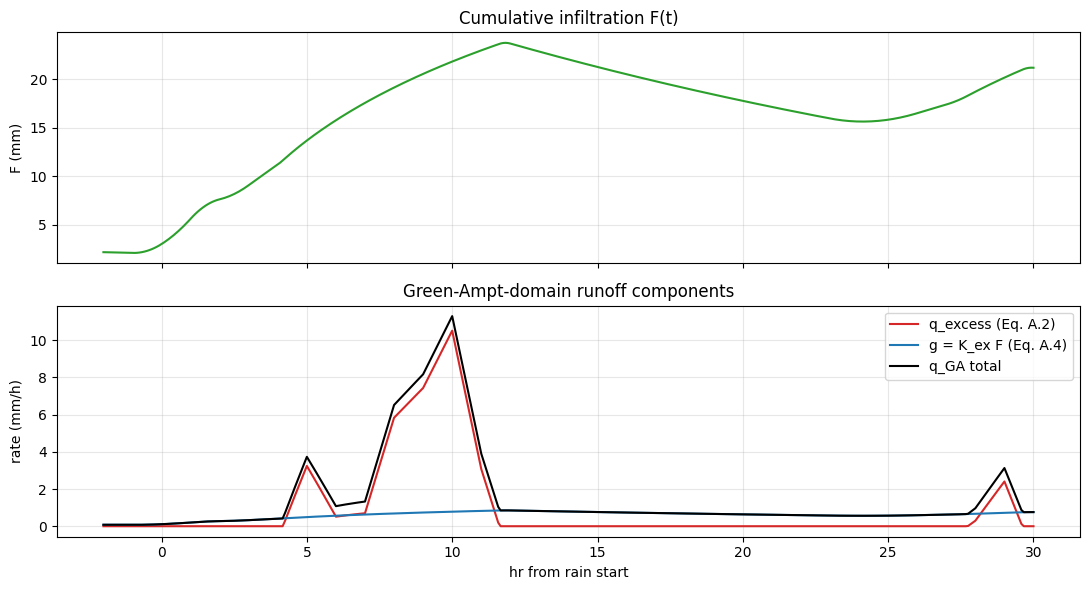

In [6]:
# Plot infiltration state and runoff components
t_h = (t_fine - WARMUP_HR * 3600) / 3600                             # display time [h from rain start]
in_show = (t_h >= -2) & (t_h <= 30)

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(t_h[in_show], F_t[in_show] * 1000, color="C2", lw=1.5)
ax[0].set_ylabel("F (mm)"); ax[0].set_title("Cumulative infiltration F(t)")
ax[0].grid(alpha=0.3)
ax[1].plot(t_h[in_show], q_excess[in_show] * 3600 * 1000, color="C3", label="q_excess (Eq. A.2)")
ax[1].plot(t_h[in_show], g_t[in_show]     * 3600 * 1000, color="C0", label="g = K_ex F (Eq. A.4)")
ax[1].plot(t_h[in_show], q_GA[in_show]    * 3600 * 1000, color="black", lw=1.5, label="q_GA total")
ax[1].set_xlabel("hr from rain start"); ax[1].set_ylabel("rate (mm/h)")
ax[1].set_title("Green-Ampt-domain runoff components")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()

## Step 2. Saturation-excess shallow storage tank

A shallow storage $S(t)$ [m] receives rainfall and drains as a
linear reservoir until full:

$$\frac{dS}{dt} = p(t) - \frac{S}{\tau_{drain}} \quad \text{(Eq.\ A.3)}$$

When $S$ would exceed $S_{max}$, the excess overflows as the
saturation-excess runoff $q_{SAT}$. Forward Euler suffices because
the overflow check is intrinsically discrete.

In [7]:
# Import sat-tank parameters
S_max     = params["S_max"]
tau_drain = params["tau_drain"]
S0_FRAC   = 0.5                                                      # initial fill fraction

# Forward Euler with overflow handling
n_t   = len(t_fine)
S_t   = np.zeros(n_t)
q_drn = np.zeros(n_t)                                                # linear drainage rate [m/s]
q_ovf = np.zeros(n_t)                                                # overflow rate [m/s]
S_t[0] = S0_FRAC * S_max
for i in range(n_t - 1):
    q_drain = S_t[i] / tau_drain                                     # drainage at current S
    S_tent  = S_t[i] + (p_t[i] - q_drain) * dt_fine                  # tentative new storage
    if S_tent > S_max:
        q_sat = (S_tent - S_max) / dt_fine                           # overflow rate
        S_new = S_max
    else:
        q_sat = 0.0
        S_new = max(S_tent, 0.0)
    S_t[i+1] = S_new
    q_drn[i] = q_drain
    q_ovf[i] = q_sat
q_drn[-1] = S_t[-1] / tau_drain                                      # final-step drainage

q_SAT      = q_drn + q_ovf                                           # SAT-domain total [m/s]
S_sat_norm = np.clip(S_t / S_max, 0.0, 1.0)                          # normalised storage state

print(f"S peak:        {S_t.max()*1000:.2f} mm  (S_max = {S_max*1000:.1f} mm)")
print(f"q_SAT peak:    {q_SAT.max()*3600*1000:.3f} mm/h")
print(f"S_sat_norm peak: {S_sat_norm.max():.3f}")

S peak:        42.08 mm  (S_max = 45.6 mm)
q_SAT peak:    3.480 mm/h
S_sat_norm peak: 0.923


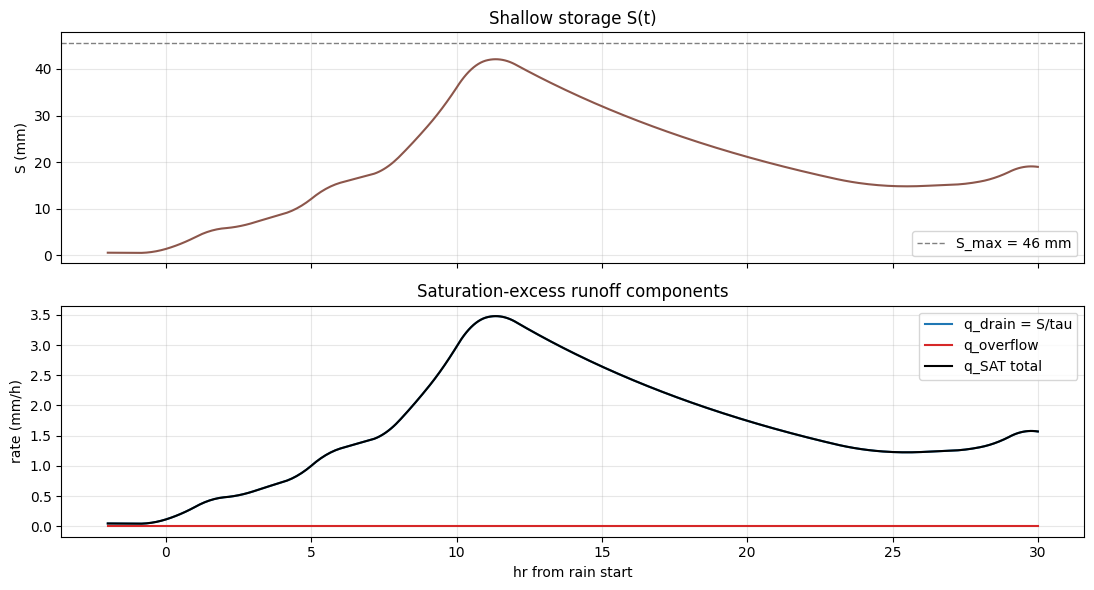

In [8]:
# Plot saturation tank state
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(t_h[in_show], S_t[in_show] * 1000, color="C5", lw=1.5)
ax[0].axhline(S_max * 1000, color="gray", ls="--", lw=1, label=f"S_max = {S_max*1000:.0f} mm")
ax[0].set_ylabel("S (mm)"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("Shallow storage S(t)")
ax[1].plot(t_h[in_show], q_drn[in_show] * 3600 * 1000, color="C0", label="q_drain = S/tau")
ax[1].plot(t_h[in_show], q_ovf[in_show] * 3600 * 1000, color="C3", label="q_overflow")
ax[1].plot(t_h[in_show], q_SAT[in_show] * 3600 * 1000, color="black", lw=1.5, label="q_SAT total")
ax[1].set_xlabel("hr from rain start"); ax[1].set_ylabel("rate (mm/h)")
ax[1].set_title("Saturation-excess runoff components")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()

## Step 3. Combine surface runoff (Eq. 1)

The catchment is partitioned by the saturated-area fraction
$f_{sat}$. The total surface runoff is

$$q_{hill,surf}(t) = (1 - f_{sat})\,q_{GA}(t) + f_{sat}\,q_{SAT}(t) \quad \text{(Eq.\ 1)}$$

In [9]:
# Combine GA and saturation pathways by f_sat
f_sat  = params["f_sat"]
q_surf = (1.0 - f_sat) * q_GA + f_sat * q_SAT                         # total surface runoff [m/s]

print(f"q_surf peak: {q_surf.max()*3600*1000:.3f} mm/h "
      f"(GA peak: {q_GA.max()*3600*1000:.3f},  SAT peak: {q_SAT.max()*3600*1000:.3f})")

q_surf peak: 9.977 mm/h (GA peak: 11.293,  SAT peak: 3.480)


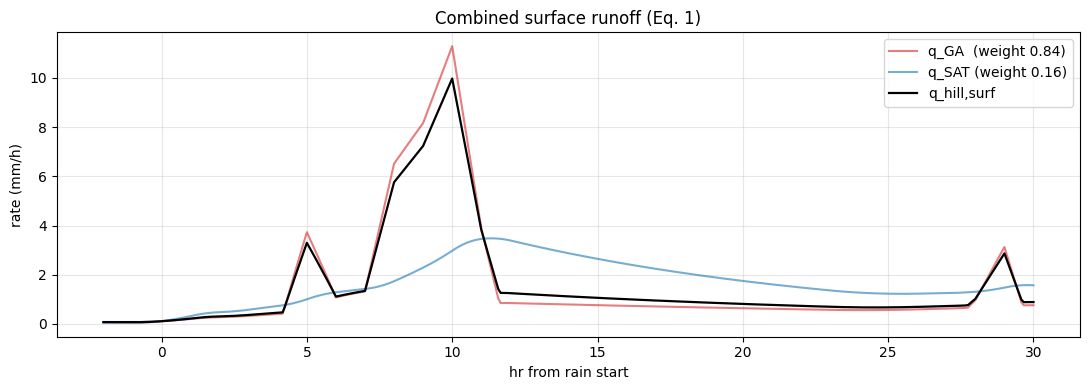

In [10]:
# Plot the weighted combination
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_h[in_show], q_GA[in_show]   * 3600 * 1000, color="C3", alpha=0.6, label=f"q_GA  (weight {1-f_sat:.2f})")
ax.plot(t_h[in_show], q_SAT[in_show]  * 3600 * 1000, color="C0", alpha=0.6, label=f"q_SAT (weight {f_sat:.2f})")
ax.plot(t_h[in_show], q_surf[in_show] * 3600 * 1000, color="black", lw=1.6, label="q_hill,surf")
ax.set_xlabel("hr from rain start"); ax.set_ylabel("rate (mm/h)")
ax.set_title("Combined surface runoff (Eq. 1)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## Step 4. Soil chloride mixing pool (CSTR)

A continuously stirred reactor of effective depth $V_{soil}$ [m]
tracks the soil-pool chloride concentration $C_{soil}(t)$:

$$\frac{d(V_{soil}\,C_{soil})}{dt} = p(t)\,C_{rain}(t) - q_{hill,surf}(t)\,C_{soil}(t) \quad \text{(Eq.\ A.5)}$$

With $V_{soil}$ constant, this reduces to

$$\frac{dC_{soil}}{dt} = \frac{p\,C_{rain} - q_{hill,surf}\,C_{soil}}{V_{soil}}$$

The initial condition (Eq. 4) is

$$C_{soil}(t = -168\,h) = \alpha_{soil}\,\cdot\,pre\_Cl$$

We integrate with LSODA (handles the stiff regime where
rainfall pulses dominate the RHS).

In [11]:
# Import soil-pool parameters
V_soil     = params["V_soil"]
alpha_soil = params["alpha_soil"]
C_soil_0   = alpha_soil * pre_Cl                                     # initial condition (Eq. 4)

# RHS of Eq. A.5: indexed lookup is faster than np.interp for stiff solvers
def dCsoil_dt(t, y):
    idx = min(max(int(np.searchsorted(t_fine, t)), 0), len(t_fine) - 1)
    return [(p_t[idx] * C_rain_t[idx] - q_surf[idx] * y[0]) / max(V_soil, 1e-6)]

# Integrate
sol = solve_ivp(dCsoil_dt, (t_fine[0], t_fine[-1]), [C_soil_0],
                 t_eval=t_fine, method="LSODA",
                 rtol=1e-3, atol=1e-4, max_step=dt_fine)
C_soil = np.clip(sol.y[0], 0.05, 100.0)                              # soil-pool Cl [mg/L]

print(f"C_soil(0)     = {C_soil_0:.3f} mg/L  (= alpha_soil * pre_Cl)")
print(f"C_soil range  = [{C_soil.min():.3f}, {C_soil.max():.3f}] mg/L")
print(f"Mixing tau    ~ V_soil / q_surf_peak ~ {V_soil/q_surf.max()/3600:.2f} hr (peak)")

C_soil(0)     = 2.954 mg/L  (= alpha_soil * pre_Cl)
C_soil range  = [2.945, 3.771] mg/L
Mixing tau    ~ V_soil / q_surf_peak ~ 78.31 hr (peak)


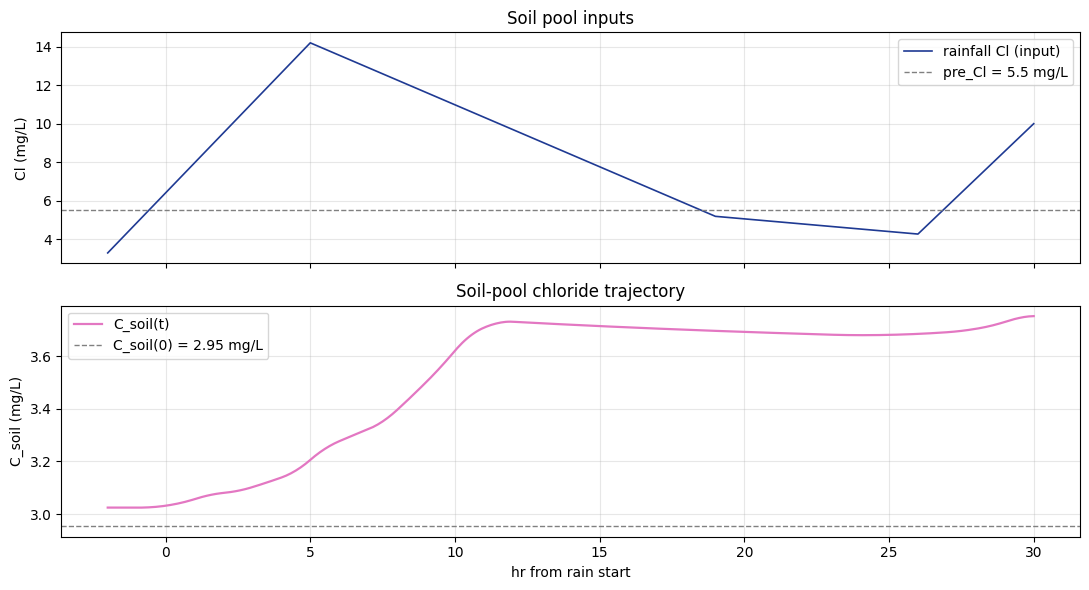

In [12]:
# Plot soil-pool Cl trajectory and forcing
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(t_h[in_show], C_rain_t[in_show], color="#1f3a93", lw=1.2, label="rainfall Cl (input)")
ax[0].axhline(pre_Cl, color="gray", ls="--", lw=1, label=f"pre_Cl = {pre_Cl:.1f} mg/L")
ax[0].set_ylabel("Cl (mg/L)"); ax[0].legend(loc="upper right")
ax[0].set_title("Soil pool inputs")
ax[0].grid(alpha=0.3)
ax[1].plot(t_h[in_show], C_soil[in_show], color="C6", lw=1.6, label="C_soil(t)")
ax[1].axhline(C_soil_0, color="gray", ls="--", lw=1, label=f"C_soil(0) = {C_soil_0:.2f} mg/L")
ax[1].set_xlabel("hr from rain start"); ax[1].set_ylabel("C_soil (mg/L)")
ax[1].set_title("Soil-pool chloride trajectory")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()

## Step 5. Empirical unit hydrograph convolution

The DEM-based UH $u(t)$ converts surface runoff (a depth
increment per fine step, $q_{surf}\,\Delta t$) into hillslope
discharge $Q_{hill}(t)$. The `uh_stretch` parameter time-stretches
the UH while preserving $\int u\,dt = 1$:

$$u_{stretched}(t) = \frac{1}{s}\,u(t/s),\quad s = uh\_stretch$$

This represents the hillslope subsurface storage delay that the
channel-only DEM UH does not capture.

In [13]:
# Import UH and stretch parameter
uh_t_hr_raw    = np.asarray(uh_npz["t_hr"])                          # raw UH times [hr]
uh_hr_inv_raw  = np.asarray(uh_npz["uh_hr_inv"])                     # raw UH ordinates [1/hr]
uh_stretch     = params["uh_stretch"]

# Stretch the UH (mass-conservative)
uh_t_hr   = uh_t_hr_raw   * uh_stretch                               # stretched times [hr]
uh_hr_inv = uh_hr_inv_raw / uh_stretch                               # rescaled ordinates [1/hr]

# Re-sample stretched UH onto the fine time grid
t_uh_end_hr = float(uh_t_hr[-1])
t_uh_sec    = np.arange(0.0, t_uh_end_hr * 3600 + dt_fine, dt_fine)
uh_on_dt    = np.interp(t_uh_sec / 3600, uh_t_hr, uh_hr_inv,
                          left=0.0, right=0.0)                       # UH on fine dt [1/hr]
u_kernel    = A_catch * uh_on_dt / 3600                              # convolution kernel [m^3/s per m]

# Convolve excess depth increments with kernel
dF_excess = q_surf * dt_fine                                         # depth increment per fine step [m]
Q_hill    = np.convolve(dF_excess, u_kernel, mode="full")[:len(t_fine)]
Q_hill    = np.maximum(Q_hill, 0.0)                                  # hillslope discharge [m^3/s]

print(f"UH peak time (raw):       {uh_t_hr_raw[np.argmax(uh_hr_inv_raw)]:.2f} hr")
print(f"UH peak time (stretched): {uh_t_hr[np.argmax(uh_hr_inv)]:.2f} hr")
print(f"Q_hill peak:              {Q_hill.max():.3f} m^3/s")

UH peak time (raw):       0.57 hr
UH peak time (stretched): 2.52 hr
Q_hill peak:              2.426 m^3/s


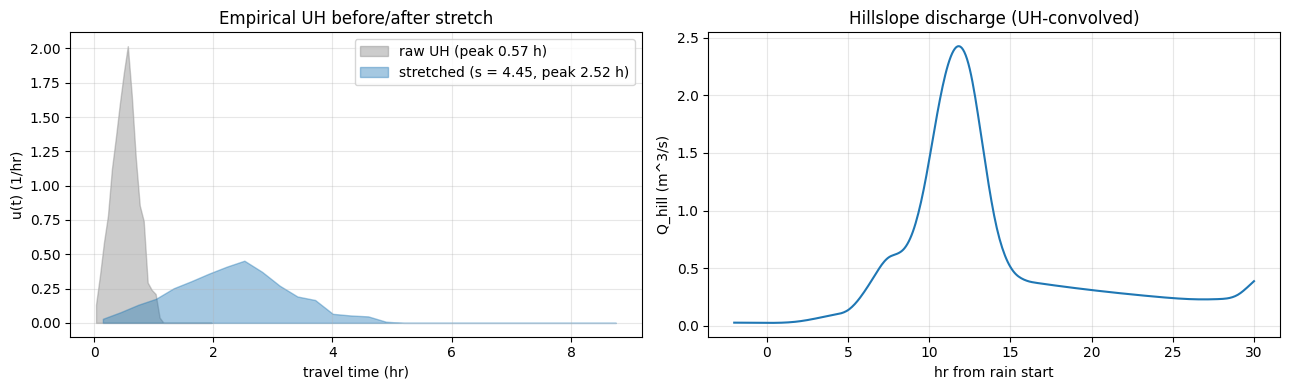

In [14]:
# Plot UH stretching and resulting Q_hill
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].fill_between(uh_t_hr_raw, 0, uh_hr_inv_raw, color="gray", alpha=0.4, label=f"raw UH (peak {uh_t_hr_raw[np.argmax(uh_hr_inv_raw)]:.2f} h)")
ax[0].fill_between(uh_t_hr,     0, uh_hr_inv,     color="C0", alpha=0.4, label=f"stretched (s = {uh_stretch:.2f}, peak {uh_t_hr[np.argmax(uh_hr_inv)]:.2f} h)")
ax[0].set_xlabel("travel time (hr)"); ax[0].set_ylabel("u(t) (1/hr)")
ax[0].set_title("Empirical UH before/after stretch")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(t_h[in_show], Q_hill[in_show], color="C0", lw=1.5)
ax[1].set_xlabel("hr from rain start"); ax[1].set_ylabel("Q_hill (m^3/s)")
ax[1].set_title("Hillslope discharge (UH-convolved)")
ax[1].grid(alpha=0.3)
plt.tight_layout()

## Step 6. Manning steady-state baseflow initial condition

Before time-stepping the channel, we need an initial state
$(h_i, Q_i, AC_i)$ for each of the $N = 20$ cells. We assume
steady baseflow with lateral inflow $q_L = baseflow\_Q / L$, so
cell $i$ carries $Q_i = q_L\,i\,\Delta x$. Manning's equation
gives the depth:

$$Q = \frac{1}{n}\,A\,R^{2/3}\,\sqrt{S_0} \quad \text{(Eq.\ A.11)}$$

with $A = B\,h$, $R = A / (B + 2h)$. We solve for $h$ via Newton
iteration. Initial chloride $A_i C_i = B\,h_i\,pre\_Cl$.

In [15]:
# Newton iteration for Manning depth (rectangular channel)
n_man      = params["n"]
baseflow_Q = params["baseflow_Q"]

def manning_h(Q_target):
    h = 0.05
    for _ in range(50):
        A_h = B_width * h
        P_h = B_width + 2.0 * h
        R_h = A_h / P_h
        Q_h = A_h * R_h**(2/3) * np.sqrt(S_0_chan) / n_man
        eps = max(1e-6, 0.001 * h)
        A2 = B_width * (h + eps);  P2 = B_width + 2*(h + eps);  R2 = A2 / P2
        Q2 = A2 * R2**(2/3) * np.sqrt(S_0_chan) / n_man
        dQ_dh = (Q2 - Q_h) / eps
        if abs(dQ_dh) < 1e-14: break
        h_new = max(h - (Q_h - Q_target) / dQ_dh, 1e-4)
        if abs(h_new - h) < 1e-10: h = h_new; break
        h = h_new
    return h

# Build initial state vector y0 = [h_1..h_N, Q_1..Q_N, (AC)_1..(AC)_N]
qL_base = baseflow_Q / L_chan                                        # uniform lateral inflow [m^2/s]
Q_init  = qL_base * (dx * (np.arange(N) + 1))                        # Q_i = q_L * i * dx
h_init  = np.array([manning_h(Q) for Q in Q_init])                   # Manning steady depths [m]
AC_init = B_width * h_init * pre_Cl                                  # initial AC = B h pre_Cl
y0 = np.concatenate([h_init, Q_init, AC_init])

print(f"baseflow_Q = {baseflow_Q:.3f} m^3/s,  Q_outlet_init = {Q_init[-1]:.3f} m^3/s")
print(f"h_init range = [{h_init.min()*100:.2f}, {h_init.max()*100:.2f}] cm")
print(f"y0 length    = {len(y0)} (3 N = {3*N})")

baseflow_Q = 0.302 m^3/s,  Q_outlet_init = 0.302 m^3/s
h_init range = [2.27, 14.29] cm
y0 length    = 60 (3 N = 60)


## Step 7. Channel routing — Saint-Venant + ADE

The channel is one-dimensional with $N = 20$ cells. Each cell
carries three states: depth $h$, discharge $Q$, and chloride mass
per unit length $AC$. The governing equations are:

**Continuity (Eq. A.9):**
$$\frac{\partial h}{\partial t} + \frac{1}{B}\frac{\partial Q}{\partial x} = q_L(x, t)$$

**Diffusion-wave momentum (Eq. A.10):** $S_f = S_0 - \partial h / \partial x$

**Manning friction (Eq. A.11):** $Q = (1/n)\,A\,R^{2/3}\sqrt{S_f}$

**Advection-dispersion (Eq. A.12):**
$$\frac{\partial(AC)}{\partial t} + \frac{\partial(QC)}{\partial x}
  = \frac{\partial}{\partial x}\!\Big(D\,\frac{\partial C}{\partial x}\Big)
  + q_L\,C_{lat}(t)$$

where $C = AC / A$ is the in-channel concentration and $C_{lat}$
is the chloride concentration of the lateral inflow, set by the
mixing closure (Eq. A.6–A.8) below.

### Mixing closure (Eq. A.6–A.8)

The lateral inflow Cl combines high-Cl baseflow with the
soil-pool $C_{soil}$ via a sigmoidal Q-dependent weight:

$$\alpha(Q) = \frac{1}{1 + (Q/Q_{thr})^{\gamma}} \quad \text{(Eq.\ A.6)}$$

$$\alpha_{eff}(Q, s) = \alpha(Q)\,(1 - \lambda_{sat}\,s_{norm}) \quad \text{(Eq.\ A.7)}$$

$$C_{lat}(t) = \alpha_{eff}\,C_b + (1 - \alpha_{eff})\,C_{soil}(t) \quad \text{(Eq.\ A.8)}$$

with $C_b = pre\_Cl$. Because $\alpha_{eff}$ depends on $Q$ but
$Q$ is what we are solving for, we use a **two-iteration
fixed-point** scheme: start from $Q = baseflow\_Q$, compute
$C_{lat}$, solve the SV+ADE system, update $Q$, repeat once.

In [16]:
# RHS of the coupled SV + ADE system (Eq. A.9-A.12)
G       = 9.81                                                       # gravity [m/s^2]
D_0     = 0.05                                                       # base dispersion [m^2/s]
BETA_D  = 0.5                                                        # dispersion-Q exponent
Q_REF   = 1.0                                                        # dispersion ref Q [m^3/s]
K_DEC   = 0.0                                                        # chloride decay rate [1/s]

def channel_rhs(t, y, qL_interp, C_lat_interp):
    """RHS for state y = [h_1..h_N, Q_1..Q_N, (AC)_1..(AC)_N]."""
    h  = np.maximum(y[:N], 1e-6)
    Q  = y[N:2*N]
    AC = y[2*N:3*N]
    A  = B_width * h                                                  # cross-sectional area [m^2]
    P  = B_width + 2*h                                                # wetted perimeter [m]
    R  = A / P                                                        # hydraulic radius [m]
    C  = np.maximum(np.where(A > 1e-8, AC / np.maximum(A, 1e-8), 0.0), 0.0)
    Sf = n_man*n_man * Q*np.abs(Q) / (A*A * R**(4/3) + 1e-12)         # friction slope (Eq. A.11)
    # Q at cell faces (staggered grid)
    Q_face = np.empty(N + 1)
    Q_face[0]    = 0.0                                                # closed upstream (headwater)
    Q_face[1:N]  = 0.5 * (Q[:-1] + Q[1:])
    Q_face[N]    = Q[-1]                                              # free outflow
    qL_t    = float(qL_interp(t))
    C_lat_t = float(C_lat_interp(t))
    # Continuity (Eq. A.9)
    dh = (qL_t - (Q_face[1:] - Q_face[:-1]) / dx) / B_width
    # Momentum, diffusion-wave form (Eq. A.10)
    h_ext = np.concatenate(([h[0]], h, [h[-1]]))
    dhdx  = (h_ext[:-2] - h_ext[2:]) / (2*dx)
    dQ    = G * A * (dhdx + S_0_chan - Sf)
    # ADE advection (upwind based on Q_face sign)
    QC_face = np.empty(N + 1)
    QC_face[0] = 0.0
    pos = Q_face[1:N] >= 0
    QC_face[1:N] = np.where(pos, Q_face[1:N] * C[:-1], Q_face[1:N] * C[1:])
    QC_face[N] = Q_face[N] * C[-1]
    dAC = -(QC_face[1:] - QC_face[:-1]) / dx
    # ADE dispersion (central difference at interior faces)
    Q_abs  = np.maximum(np.abs(Q), 1e-10)
    D_cell = D_0 * (Q_abs / Q_REF)**BETA_D
    A_face = 0.5 * (A[:-1] + A[1:])
    D_face = 0.5 * (D_cell[:-1] + D_cell[1:])
    grad_C = (C[1:] - C[:-1]) / dx
    flux_disp = A_face * D_face * grad_C
    dAC[:-1] += flux_disp / dx
    dAC[1:]  -= flux_disp / dx
    # Source (lateral) and decay
    dAC += qL_t * C_lat_t
    dAC -= K_DEC * AC
    return np.concatenate([dh, dQ, dAC])

In [17]:
# Build lateral inflow and prepare interpolators on the hourly output grid
Q_threshold = params["Q_threshold"]
gamma       = params["gamma"]
lambda_sat  = params["lambda_sat"]

t_eval = rain_t.copy()                                               # hourly output grid [s]
t_end  = float(t_eval[-1])

# Total lateral inflow per unit length: hillslope + steady baseflow
qL_fine    = Q_hill / L_chan + baseflow_Q / L_chan                   # [m^2/s]
qL_interp  = interp1d(t_fine, qL_fine, bounds_error=False,
                       fill_value=(qL_fine[0], qL_fine[-1]))

# Soil-pool Cl interpolator for the mixing closure
C_soil_interp = interp1d(t_fine, C_soil, bounds_error=False,
                          fill_value=(C_soil[0], C_soil[-1]))
S_sat_norm_interp = interp1d(t_fine, S_sat_norm, bounds_error=False,
                              fill_value=(S_sat_norm[0], S_sat_norm[-1]))

# Dense grid for the fixed-point iteration on Q-mixing
t_mix      = np.linspace(0.0, t_end, 500)                            # mix-update grid [s]
C_soil_mix = np.array([float(C_soil_interp(t)) for t in t_mix])      # soil Cl on mix grid
S_sat_mix  = np.array([float(S_sat_norm_interp(t)) for t in t_mix])  # sat-norm on mix grid

# Fixed-point iteration: Q -> alpha(Q) -> C_lat -> solve channel -> new Q
Q_guess = baseflow_Q * np.ones_like(t_mix)                           # initial guess: steady baseflow
C_b     = pre_Cl                                                     # baseflow Cl endmember
sol = None
for itr in range(2):
    # Eq. A.6: sigmoidal Q-dependent mixing weight
    alpha_v = 1.0 / (1.0 + (np.maximum(Q_guess, 1e-10) / Q_threshold)**gamma)
    # Eq. A.7: state-dependent damping (Model B)
    alpha_v = np.clip(alpha_v * (1.0 - lambda_sat * S_sat_mix), 0.0, 1.0)
    # Eq. A.8: two-endmember mixing
    C_lat_mix = alpha_v * C_b + (1.0 - alpha_v) * C_soil_mix
    C_lat_interp = interp1d(t_mix, C_lat_mix, bounds_error=False,
                             fill_value=(C_lat_mix[0], C_lat_mix[-1]))
    # Solve coupled SV + ADE on the hourly output grid
    sol = solve_ivp(
        lambda t, y: channel_rhs(t, y, qL_interp, C_lat_interp),
        (0.0, t_end), y0, t_eval=t_eval, method="LSODA",
        rtol=1e-2, atol=1e-4, max_step=300.0,
    )
    # Update Q guess from this solve (outlet cell)
    Q_outlet = sol.y[2*N - 1]
    Q_guess  = np.interp(t_mix, t_eval, Q_outlet)
    print(f"  Iteration {itr+1}: Q_outlet peak = {Q_outlet.max():.3f} m^3/s,  alpha range = [{alpha_v.min():.3f}, {alpha_v.max():.3f}]")

# Extract outlet streamflow and chloride
h_out  = sol.y[N - 1]
Q_out  = sol.y[2*N - 1]
AC_out = sol.y[3*N - 1]
A_out  = B_width * np.maximum(h_out, 1e-6)
C_out  = np.maximum(np.where(A_out > 1e-8, AC_out / A_out, 0.0), 0.0)

print(f"\nFinal outlet:  Q peak = {Q_out.max():.3f} m^3/s,  C range = [{C_out.min():.2f}, {C_out.max():.2f}] mg/L")

  Iteration 1: Q_outlet peak = 2.716 m^3/s,  alpha range = [0.802, 0.941]
  Iteration 2: Q_outlet peak = 2.716 m^3/s,  alpha range = [0.140, 0.933]

Final outlet:  Q peak = 2.716 m^3/s,  C range = [3.99, 5.50] mg/L


## Compare simulated outlet against observations

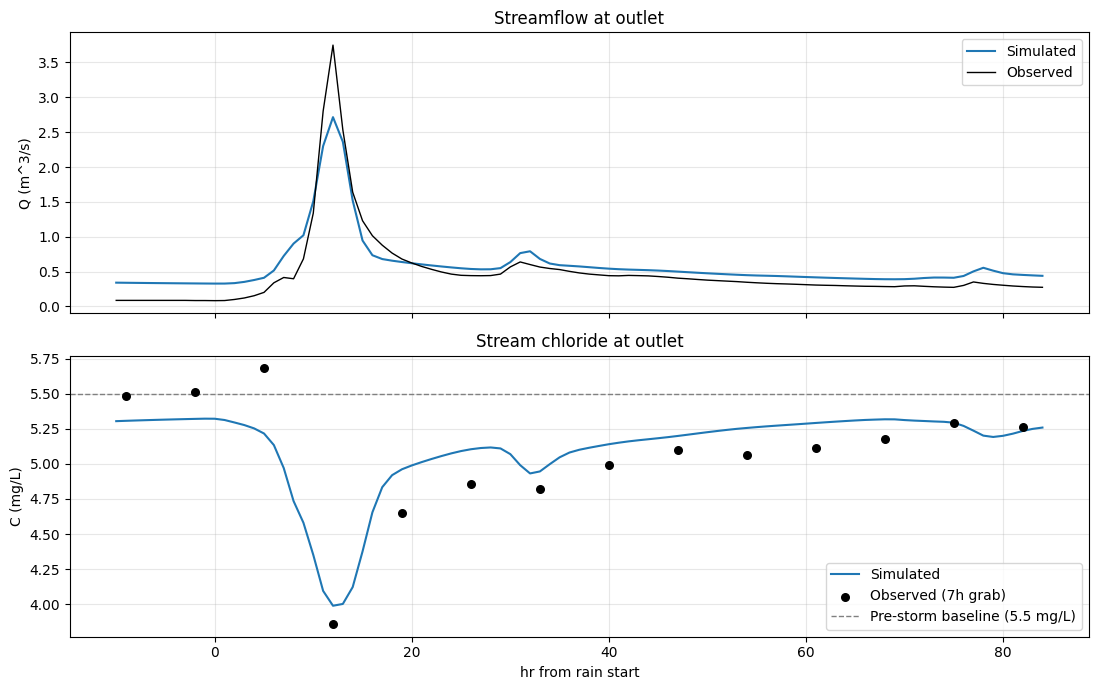

In [18]:
# Display range and observed Cl markers
t_h_hourly = (t_eval - WARMUP_HR * 3600) / 3600
show_h     = (t_h_hourly >= -10) & (t_h_hourly <= 84)
cstream_t  = (cstream["t_sec"].values - WARMUP_HR * 3600) / 3600
m_obs      = (cstream_t >= -10) & (cstream_t <= 84)

fig, (ax_Q, ax_C) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax_Q.plot(t_h_hourly[show_h], Q_out[show_h], color="C0", lw=1.5, label="Simulated")
ax_Q.plot(t_h_hourly[show_h], Q_obs[show_h], color="black", lw=1.0, label="Observed")
ax_Q.set_ylabel("Q (m^3/s)"); ax_Q.legend(); ax_Q.grid(alpha=0.3)
ax_Q.set_title("Streamflow at outlet")
ax_C.plot(t_h_hourly[show_h], C_out[show_h], color="C0", lw=1.5, label="Simulated")
ax_C.scatter(cstream_t[m_obs], cstream["Cl_mgL"].values[m_obs],
              color="black", s=30, zorder=5, label="Observed (7h grab)")
ax_C.axhline(pre_Cl, color="gray", ls="--", lw=1, label=f"Pre-storm baseline ({pre_Cl:.1f} mg/L)")
ax_C.set_xlabel("hr from rain start"); ax_C.set_ylabel("C (mg/L)")
ax_C.legend(); ax_C.grid(alpha=0.3)
ax_C.set_title("Stream chloride at outlet")
plt.tight_layout()

## Mass balance check

This cell computes the chloride mass balance for the *simulated* outflow
under the balanced-best parameter set above. It is a sanity check that
the model conserves mass to within numerical tolerance over the
calibration window, not a reproduction of the observation-based mass
balance reported in Section 4.3 of the manuscript.

The numbers here will differ from the manuscript's Appendix E (1010 kg
in / 732 kg out / 28% retention) for two reasons:

1. The Cl output here is the *simulated* `Q_out * C_out` integrated
   on the hourly grid, while Section 4.3 uses the *observed* hourly
   streamflow multiplied by the linearly interpolated observed
   stream chloride.
2. The "storm runoff" reported here is `(Q - baseflow_Q) * dt`
   (i.e., the model's event-component runoff with the constant
   baseflow term subtracted), while the manuscript's runoff
   coefficient discussion uses the total streamflow volume.


In [19]:
# Mass balance over the calibration window [rain start, +84 h]
# All quantities below are SIMULATED outputs from the balanced-best run.
# See the markdown above for the comparison with observation-based
# Section 4.3 / Appendix E values.
in_cal = (t_h >= 0) & (t_h <= 84)                                    # fine-grid window
V_in   = A_catch * np.sum(p_t[in_cal]) * dt_fine                     # rainfall input volume [m^3]
rain_depth_mm = V_in / A_catch * 1000                                # rainfall depth [mm]

in_cal_h = (t_h_hourly >= 0) & (t_h_hourly <= 84)                    # hourly-grid window
dt_h = 3600.0                                                        # hourly step [s]
V_total_out = np.sum(Q_out[in_cal_h]) * dt_h                         # total streamflow volume [m^3]
V_event_out = np.sum(np.maximum(Q_out[in_cal_h] - baseflow_Q, 0)) * dt_h   # event component [m^3]
total_runoff_mm = V_total_out / A_catch * 1000
event_runoff_mm = V_event_out / A_catch * 1000

# Simulated chloride mass balance
cl_in_kg  = A_catch * np.sum(p_t[in_cal] * C_rain_t[in_cal]) * dt_fine / 1000
cl_out_kg = np.sum(Q_out[in_cal_h] * C_out[in_cal_h]) * dt_h / 1000

print("--- Water mass balance (simulated) ---")
print(f"  Rainfall depth (0-84 h):       {rain_depth_mm:7.1f} mm")
print(f"  Total simulated streamflow:    {total_runoff_mm:7.1f} mm")
print(f"  Event component (Q-baseflow):  {event_runoff_mm:7.1f} mm")
print(f"  Total runoff coefficient:      {total_runoff_mm/rain_depth_mm:7.2f}")
print(f"  Event runoff coefficient:      {event_runoff_mm/rain_depth_mm:7.2f}")
print()
print("--- Chloride mass balance (simulated) ---")
print(f"  Rainfall Cl input:             {cl_in_kg:7.1f} kg")
print(f"  Stream Cl output (simulated):  {cl_out_kg:7.1f} kg")
print(f"  Net catchment retention:       {cl_in_kg - cl_out_kg:7.1f} kg "
      f"({100*(cl_in_kg - cl_out_kg)/cl_in_kg:.0f}% of input)")
print()
print("Manuscript Section 4.3 reports observation-based balance:")
print("  1090 kg in, 748 kg out, ~28% retention")
print("(observed Q * observed Cl_interp; this notebook uses simulated quantities)")


--- Water mass balance (simulated) ---
  Rainfall depth (0-84 h):          84.1 mm
  Total simulated streamflow:      152.8 mm
  Event component (Q-baseflow):     77.0 mm
  Total runoff coefficient:         1.82
  Event runoff coefficient:         0.92

--- Chloride mass balance (simulated) ---
  Rainfall Cl input:              1015.5 kg
  Stream Cl output (simulated):    913.7 kg
  Net catchment retention:         101.7 kg (10% of input)

Manuscript Section 4.3 reports observation-based balance:
  1090 kg in, 748 kg out, ~28% retention
(observed Q * observed Cl_interp; this notebook uses simulated quantities)


## Cross-check with the `uhf_sir.Model` class

As a final sanity check, run the same simulation through the
class API and compare outlet Q and C.

In [19]:
from uhf_sir import Model

# Build the same input dicts expected by the class
storm_data = {
    "rain_t":     rain_t,
    "rain_flux":  rain_flux,
    "rain_C":     rain_C_grid,
    "t_Q_hourly": rain_t,
    "pre_Cl":     pre_Cl,
}
site = {
    "catchment_area_km2": 1.219,
    "L_channel":          L_chan,
    "B_width":            B_width,
    "S_0":                S_0_chan,
    "uh_t_hr":            uh_t_hr_raw,
    "uh_hr_inv":          uh_hr_inv_raw,
}

mclass = Model(storm_data, params, site, N=N, dt_fine=dt_fine)
mclass.simulate(force_alpha_one=False)

print(f"Notebook  Q peak: {Q_out.max():.4f} m^3/s,  C trough: {C_out.min():.4f} mg/L")
print(f"Class     Q peak: {mclass.Q_out.max():.4f} m^3/s,  C trough: {mclass.C_out.min():.4f} mg/L")
print(f"Max |Q_diff|:  {np.max(np.abs(mclass.Q_out - Q_out)):.6f} m^3/s")
print(f"Max |C_diff|:  {np.max(np.abs(mclass.C_out - C_out)):.6f} mg/L")

Notebook  Q peak: 2.7155 m^3/s,  C trough: 3.9896 mg/L
Class     Q peak: 2.7155 m^3/s,  C trough: 3.9896 mg/L
Max |Q_diff|:  0.000000 m^3/s
Max |C_diff|:  0.000000 mg/L
